In [170]:
import sklearn
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import numpy as np  # package for arrays
import matplotlib.pyplot as plt  # package for plotting
from time import time 
import random as ran

In [171]:
'''

Tcs are:

x=1 : 2.269
x=0.9 : 1.9
x=0.8 : 1.5
x=0.7 : 1.05
x=0.6 : 0.2

'''

'\n\nTcs are:\n\nx=1 : 2.269\nx=0.9 : 1.9\nx=0.8 : 1.5\nx=0.7 : 1.05\nx=0.6 : 0.2\n\n'

In [172]:
def get_details(y):
    temps = set(y)
    temps = np.sort(np.array(list(temps)))
    np.sort([1,])
    Tcount = {}
    for kT in temps:
        Tcount[kT] = np.count_nonzero(y==kT)
    return Tcount

def order_data(y, X):
    indices = np.argsort(y)
    y = y[indices]
    X = X[indices]
    return (y, X)

def reconstruct_lattice(lattice):
    L = round(np.sqrt(len(lattice)))
    return np.reshape(lattice, (L,L))

def show_state(state):
    img = reconstruct_lattice(state)
    _, ax = plt.subplots()
    ax.imshow(img, cmap=plt.get_cmap('gray'), interpolation="nearest")
    
def load_data(method, L, x):
    path = 'data/'+method+'/L='+str(L)+'_x='+str(x)
    X = np.loadtxt(path+'_X.txt') 
    y = np.loadtxt(path+'_y.txt') 

    y, X = order_data(y, X)
    return y, X

### Data

In [282]:
x = 0.9

y50, X50 = load_data(method='up_down', L=50, x=x)
y40, X40 = load_data(method='up_down', L=40, x=x)
y30, X30 = load_data(method='up_down', L=30, x=x)

print(y40.shape)
get_details(y30)

(1420,)


{1.1: 91,
 1.2: 91,
 1.3: 89,
 1.4: 89,
 1.5: 93,
 1.6: 68,
 1.7: 73,
 1.8: 86,
 1.9: 97,
 2.0: 97,
 2.1: 89,
 2.2: 89,
 2.3: 83,
 2.4: 87,
 2.5: 98,
 2.6: 93,
 2.7: 87}

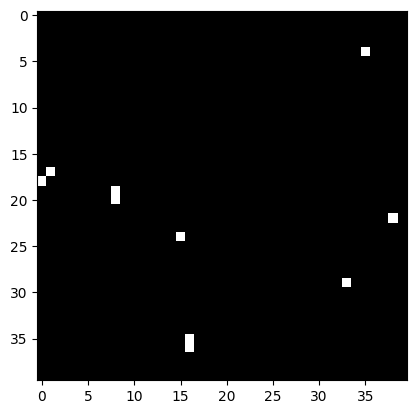

In [7]:
show_state(X40[4])

### Mean absolute value + error bars

In [71]:
def mean_absolute(y, values, central_limit=True):
    temperatures = list(set(y))
    
    means = []
    errs = []
    for kT in temperatures:
        filt = y==kT
        samples = values[filt]
        N_samples = len(samples)
        
        samples = np.abs(samples)
        mean = np.mean(samples)
        if central_limit:
            err = np.std(samples)/np.sqrt(N_samples)
        else:
            err = np.std(samples)
        
        errs.append(err)
        means.append(mean)
        
    return temperatures, means, errs
    
def reorder(temperatures, values, errs='None'):
    temperatures = np.array(temperatures)
    values = np.array(values)
    errs = np.array(errs)
    
    indices = np.argsort(temperatures)
    
    if errs != 'None':
        return temperatures[indices], values[indices], errs[indices]
    
    return temperatures[indices], values[indices]

def get_mean_errs(values, central_limit=True):
    mean = np.mean(values)
    if central_limit:
        err = np.std(values)/np.sqrt(len(values))
    else:
        err = np.std(values)
    return mean, err

def function()

### Magnetisation


In [53]:
def magnetisation(state):
    N = np.count_nonzero(state)
    return np.sum(state)/N

def mags(states):
    m = []
    for state in states:
        m.append(magnetisation(state))
    return np.array(m)

def get_m(X, y):
    m = mags(X)
    T, M, err = mean_absolute(y, m, central_limit=True)
    T, M, err = reorder(T, M, err)
    return T, M, err

In [61]:
r'$k=2$'

'$k=2$'

/var/folders/v_/fs61ry8x6h9dg62cykggbxh00000gn/T/ipykernel_57453/842564004.py:30: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if errs != 'None':


Text(0.5, 0, 'T')

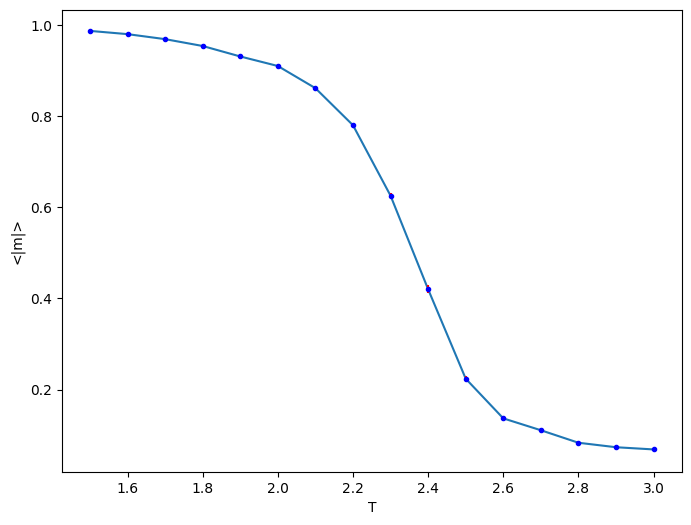

In [66]:
fig, ax = plt.subplots(figsize=(8,6))

T40, M40, err40 = get_m(X40, y40)

ax.plot(T40, M40, color='green')
ax.errorbar(T40, M40, yerr=err40, fmt='.', color='green', ecolor='red')

ax.set_title('Magnetisation vs Temperature for L=40')
ax.set_ylabel('<|m|>')
ax.set_xlabel('T')

In [ ]:
T30, M30, err30 = get_m(X30, y30)
T40, M40, err40 = get_m(X40, y40)
T50, M50, err50 = get_m(X50, y50)

plt.errorbar(T30, M30, yerr=err30, fmt='.', ecolor='red')
plt.errorbar(T40, M40, yerr=err40, fmt='.', ecolor='red')
plt.errorbar(T50, M50, yerr=err50, fmt='.', ecolor='red')

# plt.plot(T30, M30)
# plt.plot(T40, M40)
# plt.plot(T50, M50)

### Finding Tc from the point where the gradient is the steepest

### Magnetic susceptibility 

$$ \chi = \frac{1}{k_B T} \left( \langle m^2 \rangle - \langle |m| \rangle^2 \right) $$

idk if the absolute is true there

x_err = sqrt((s_err/a_err)^2 + (2a/kT)^2*a_err^2)

In [116]:
def susceptibility(values, y):
    temperatures = list(set(y))
    squares = values**2
    absolutes = np.abs(values) # aboslutes to the power of p
    
    CHI = []
    ERRs = []
    for kT in temperatures:
        filt = y==kT
        squares_ = squares[filt]
        absolutes_ = absolutes[filt]
        
        measurements = 15
        interval = round(len(squares_)/measurements)
        chis = []
        for i in range(measurements):
            s, s_err = get_mean_errs(squares_[i:(i+1)*interval]) # this may cause an issue on the last one. it may be out of range
            a, a_err = get_mean_errs(absolutes_[i:(i+1)*interval])
            x = (s - a**2)/kT
            chis.append(x)
        
        chi, err = get_mean_errs(chis)
        
        CHI.append(chi)
        ERRs.append(err)
               
    return CHI, ERRs

def get_susceptibility(y, X):
    T = list(set(y))
    m = mags(X)
    CHI, ERRs = susceptibility(m, y)
    T, CHI, ERRs = reorder(T, CHI, ERRs)
    
    return T, CHI, ERRs

In [117]:
np.std(np.array([20,25]))

2.5

/var/folders/v_/fs61ry8x6h9dg62cykggbxh00000gn/T/ipykernel_57453/181210518.py:30: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if errs != 'None':


Text(0.5, 0, 'T')

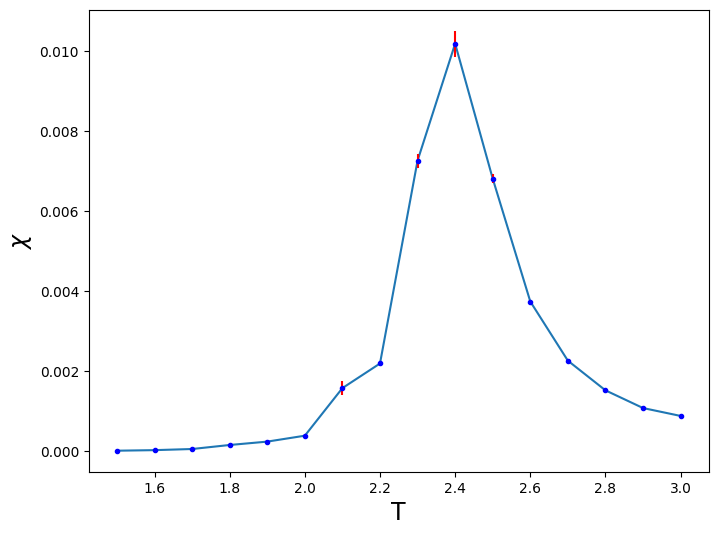

In [128]:
T40, CHI40, E40 = get_susceptibility(y40, X40)

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(T40, CHI40)
ax.errorbar(T40, CHI40, yerr=E40, fmt='.', color='blue', ecolor='red')

ax.set_ylabel(r'$\chi$', fontsize=17)
ax.set_xlabel('T', fontsize=17)

### Specific Heat (it is NOT the same as magnetic susceptibility)

$$ C_v = \sigma_E^2/T^2 $$

where $\sigma_E$ is the std of the energy

Note: we are setting k=1 and J=1

In [169]:
def energy(state):
    # reconstruct shape
    N = len(state)
    L = round(np.sqrt(N))
    state = np.reshape(state, (L,L))
    
    J = 1 # this is what it is for everything
    
    E = 0
    for i,row in enumerate(state):
        for j,spin in enumerate(row):
            
            
            NNa = state[(i-1, j)] # Nearest neighbor above
            NNl = state[(i, j-1)] # Nearest neighbor left
            if i == L-1:
                NNb = state[(0, j)]
            else:
                NNb = state[(i+1, j)]
            if j == L-1:
                NNr = state[(i, 0)]
            else:
                NNr = state[(i, j+1)]
            
            E -= J*spin*(NNb + NNa + NNl + NNr)
    
    return E/2 # we counted each connection twice so we need to divide the energy by 2

def energies(X):
    H = []
    for state in X:
        H.append(energy(state))
    return np.array(H)

def specific_heat(y, energies):
    temperatures = list(set(y))
    
    Cv = []
    for T in temperatures:
        filt = y==T
        energies_ = energies[filt]
        sigma = np.std(energies_)
        Cv.append((sigma/T)**2)
        
    return Cv

def get_Cv(y, X):
    H = energies(X)
    Cv = specific_heat(y, H)
    T = list(set(y))
    
    return T, Cv

In [170]:
T30, Cv30 = get_Cv(y30, X30)
T40, Cv40 = get_Cv(y40, X40)
T50, Cv50 = get_Cv(y50, X50)

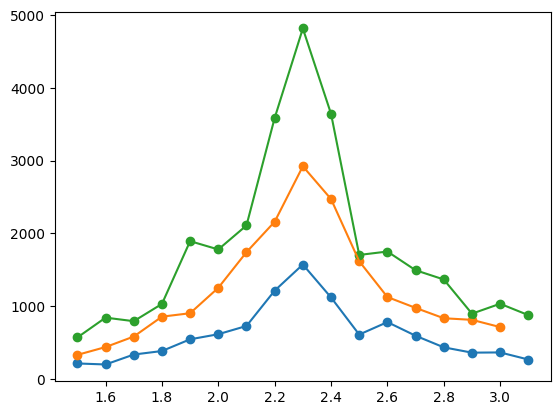

In [171]:
T30, Cv30 = reorder(T30, Cv30)
T40, Cv40 = reorder(T40, Cv40)
T50, Cv50 = reorder(T50, Cv50)

plt.scatter(T30, Cv30)
plt.scatter(T40, Cv40)
plt.scatter(T50, Cv50)

plt.plot(T30, Cv30)
plt.plot(T40, Cv40)
plt.plot(T50, Cv50)

### Binder ratios

$$ Q = \frac{<m^2>}{<|m|>^2} $$

$ x = <m^2> $ and $ y = <|m|> $ then $ Q = z = x/(y^2) $

To find the error in z, $z_{err}$, in terms of the errors in x and y, $x_{err}$ and $y_{err}$ respectively, we can use the formula for the propagation of uncertainties:

$$z_{err} = \sqrt{\left(\frac{\partial z}{\partial x} \cdot x_{err}\right)^2 + \left(\frac{\partial z}{\partial y} \cdot y_{err}\right)^2}$$

Taking the partial derivatives of z with respect to x and y, we get:

$$\frac{\partial z}{\partial x} = \frac{1}{y^2}$$

and

$$\frac{\partial z}{\partial y} = \frac{-2x}{y^3}$$

Substituting these into the formula above, we get:

$$z_{err} = \sqrt{\left(\frac{1}{y^2} \cdot x_{err}\right)^2 + \left(\frac{-2x}{y^3} \cdot y_{err}\right)^2}$$

Simplifying this expression, we get:

$$z_{err} = \sqrt{\frac{x_{err}^2}{y^4} + \frac{4x^2 y_{err}^2}{y^6}}$$

which can be further simplified as:

$$z_{err} = \frac{1}{y^3} \sqrt{x_{err}^2 y^2 + 4x^2 y_{err}^2}$$

Therefore, the error in z, $z_{err}$, in terms of the errors in x and y, $x_{err}$ and $y_{err}$ respectively, is:

$$z_{err} = \frac{1}{y^3} \sqrt{x_{err}^2 y^2 + 4x^2 y_{err}^2}$$






In [146]:
def binder(y, values, p=1):
    temperatures = list(set(y))
    squares = values**(2*p)
    absolutes = np.abs(values)**p # aboslutes to the power of p
    
    Q = []
    ERRs = []
    for kT in temperatures:
        filt = y==kT
        squares_ = squares[filt]
        absolutes_ = absolutes[filt]
        
        measurements = 10
        interval = round(len(squares_)/measurements)
        qs = []
        for i in range(measurements):
            s, s_err = get_mean_errs(squares_[i:(i+1)*interval]) # this may cause an issue on the last one. it may be out of range
            a, a_err = get_mean_errs(absolutes_[i:(i+1)*interval])
            q = s/(a**2)
            qs.append(q)
        
        q, err = get_mean_errs(qs)
        
        Q.append(q)
        ERRs.append(err)
    
    return Q, ERRs 

def get_binder(y, X):
    T = list(set(y))
    m = mags(X)
    Q, errs = binder(y, m)
#     T, Q, errs = reorder(T, Q, errs)
    
    return T, Q, errs

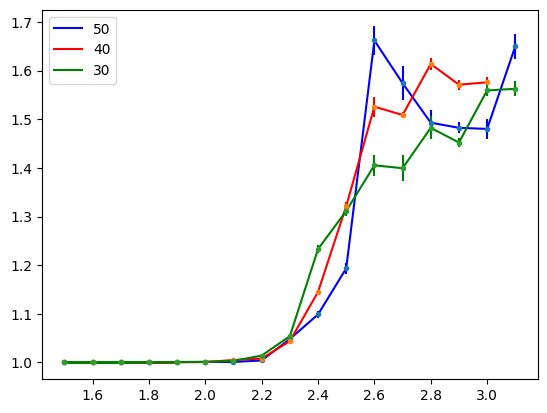

In [147]:
T50, Q50, E50 = get_binder(y50, X50)
T40, Q40, E40 = get_binder(y40, X40)
T30, Q30, E30 = get_binder(y30, X30)

plt.plot(T50, Q50, label='50', color='blue')
plt.plot(T40, Q40, label='40', color='red')
plt.plot(T30, Q30, label='30', color='green')

plt.errorbar(T50, Q50, yerr=E50, fmt='.', ecolor='blue')
plt.errorbar(T40, Q40, yerr=E40, fmt='.', ecolor='red')
plt.errorbar(T30, Q30, yerr=E30, fmt='.', ecolor='green')

plt.legend()

In [148]:
def crossing(a1, b1, a2, b2, ta, tb):
    m1 = (b1-a1)/(tb-ta)
    m2 = (b2-a2)/(tb-ta)
    
    c1 = b1 - tb*(a1-b1)/(ta-tb)
    c2 = b2 - tb*(a2-b2)/(ta-tb)
    
    t = (c2-c1)/(m1-m2)
    
    y_ = m1*t + c1
    
    return (t, y_)

def find_crossings(T1, Q1, E1, T2, Q2, E2, left_index):
    il = left_index
    ir = il + 1
    
    ta = T1[il]
    tb = T1[ir]
    
    a1up = Q1[il] + E1[il]
    b1up = Q1[ir] + E1[ir]
    a1down = Q1[il] - E1[il]
    b1down = Q1[ir] - E1[ir]
    
    a2up = Q2[il] + E2[il]
    b2up = Q2[ir] + E2[ir]
    a2down = Q2[il] - E2[il]
    b2down = Q2[ir] - E2[ir]
    
    crossing_1 = crossing(a1up, b1up, a2down, b2down, ta, tb)
    crossing_2 = crossing(a1down, b1down, a2up, b2up, ta, tb)
    
    return crossing_1, crossing_2

We see the L=50 crossings are between 2.5 and 2.6



In [149]:
(Tc1, _), (Tc2, _) = find_crossings(T50, Q50, E50, T40, Q40, E40, 10)
(Tc3, _), (Tc4, _) = find_crossings(T50, Q50, E50, T30, Q30, E30, 10)
(Tc5, _), (Tc6, _) = find_crossings(T40, Q40, E40, T30, Q30, E30, 9)

Tc_s = np.array([Tc1, Tc2, Tc3, Tc4, Tc5, Tc6])

In [150]:
err = (max(Tc_s) - min(Tc_s))/2
Tc = np.mean(Tc_s)

print(Tc)
print(err)

2.524420193618803
0.04463008879079533


In [151]:
print('Tc: 2.51 +- 0.06')

Tc: 2.51 +- 0.06


# PCA

In [283]:
reduced_data = PCA(n_components=2).fit_transform(X40)
p1 = reduced_data[:, 0]
p2 = reduced_data[:, 1]
y = y40

### Analogy to magnetisation and magnetic susceptibility

In [284]:
temperatures, p1_mean, err1 = mean_absolute(y, p1)
temperatures, p2_mean, err2 = mean_absolute(y, p2)

/var/folders/v_/fs61ry8x6h9dg62cykggbxh00000gn/T/ipykernel_57453/181210518.py:30: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if errs != 'None':


Text(0.5, 0, 'T')

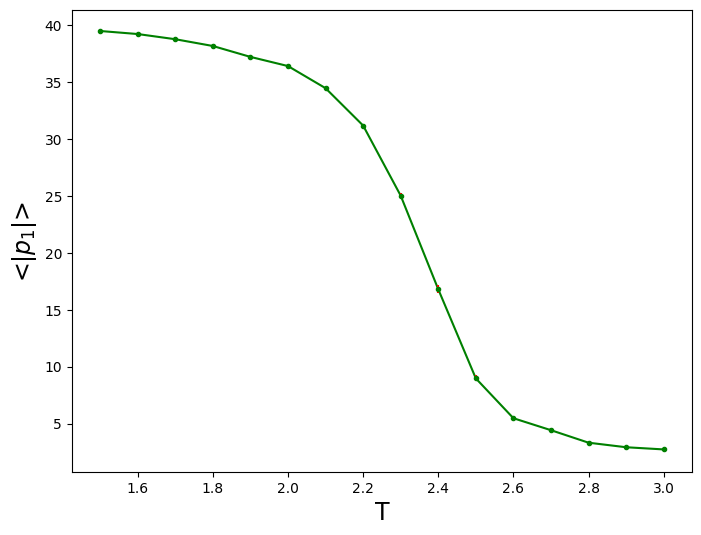

In [177]:
fig, ax = plt.subplots(figsize=(8,6))

temperatures, p1_mean, err1 = reorder(temperatures, p1_mean, err1)

ax.plot(temperatures, p1_mean, color='green')
ax.errorbar(temperatures, p1_mean, yerr=err1, fmt='.', color='green', ecolor='red')

ax.set_ylabel(r'<|$p_1$|>', fontsize=17)
ax.set_xlabel('T', fontsize=17)

/var/folders/v_/fs61ry8x6h9dg62cykggbxh00000gn/T/ipykernel_57453/181210518.py:30: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if errs != 'None':


Text(0.5, 0, 'T')

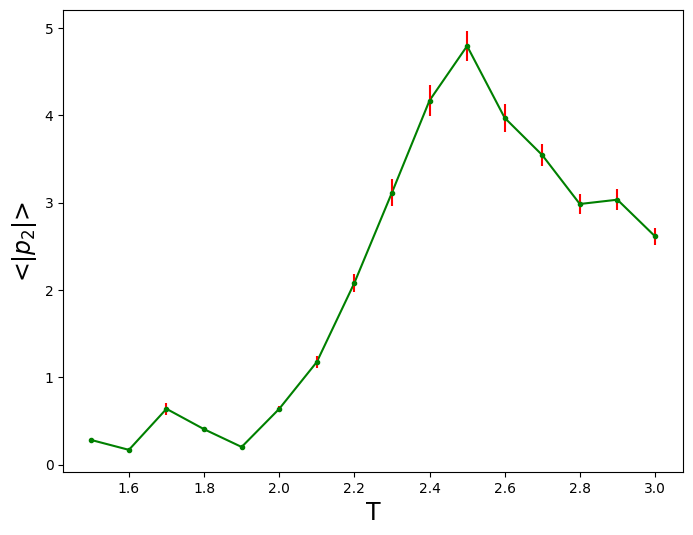

In [196]:
fig, ax = plt.subplots(figsize=(8,6))

temperatures, p2_mean, err2 = reorder(temperatures, p2_mean, err2)

ax.plot(temperatures, p2_mean, color='green')
ax.errorbar(temperatures, p2_mean, yerr=err2, fmt='.', color='green', ecolor='red')

ax.set_ylabel(r'<|$p_2$|>', fontsize=17)
ax.set_xlabel('T', fontsize=17)

Text(0.5, 1.0, '<|p2|> vs T')

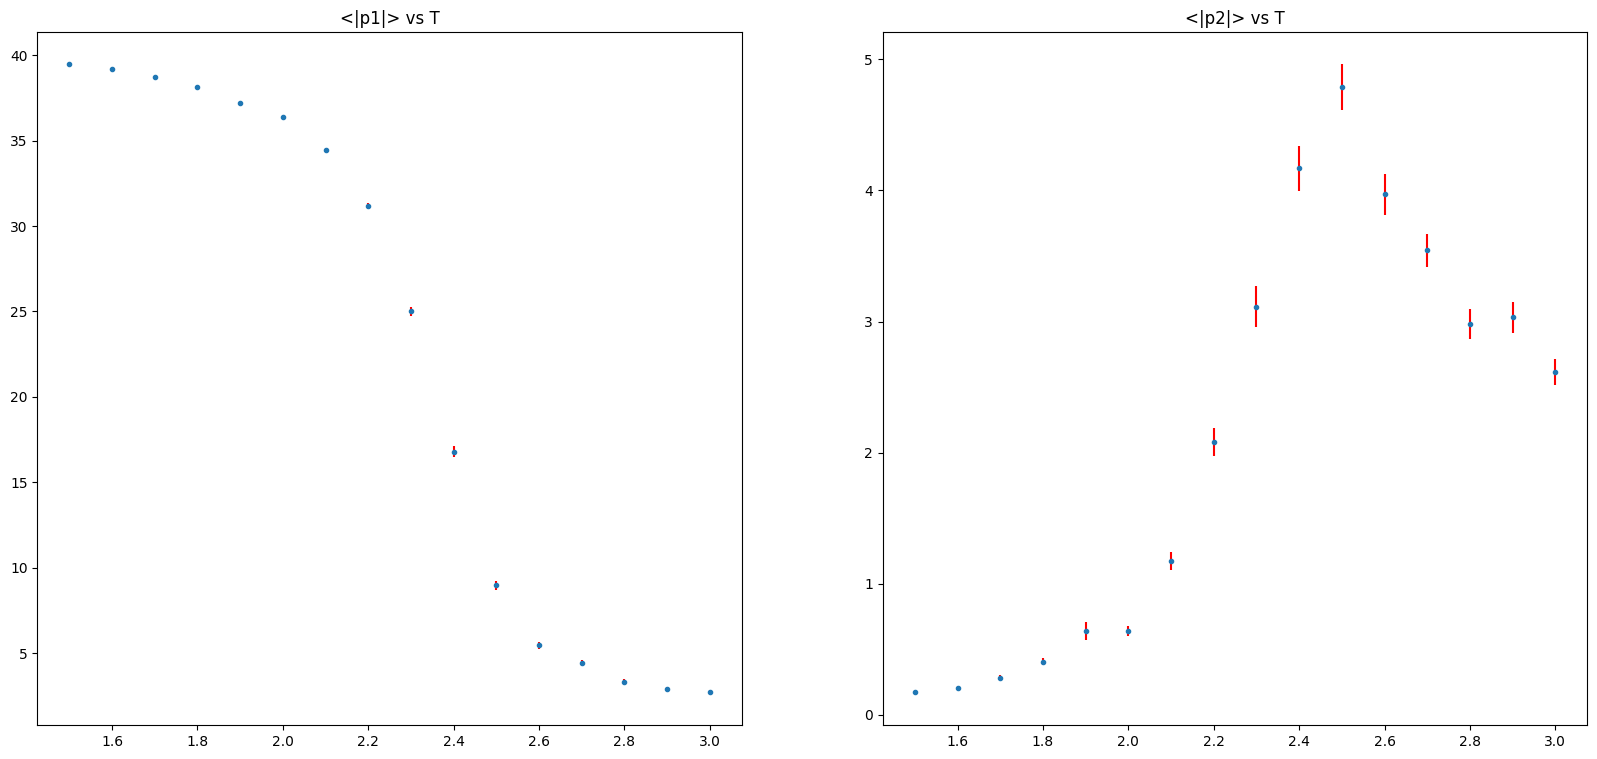

In [154]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,9))

# axs[0].scatter(temperatures, p1_mean)
axs[0].errorbar(temperatures, p1_mean, yerr=err1, fmt='.', ecolor='red')
axs[0].set_title('<|p1|> vs T')

axs[1].errorbar(temperatures, p2_mean, yerr=err2, fmt='.', ecolor='red')
axs[1].set_title('<|p2|> vs T')


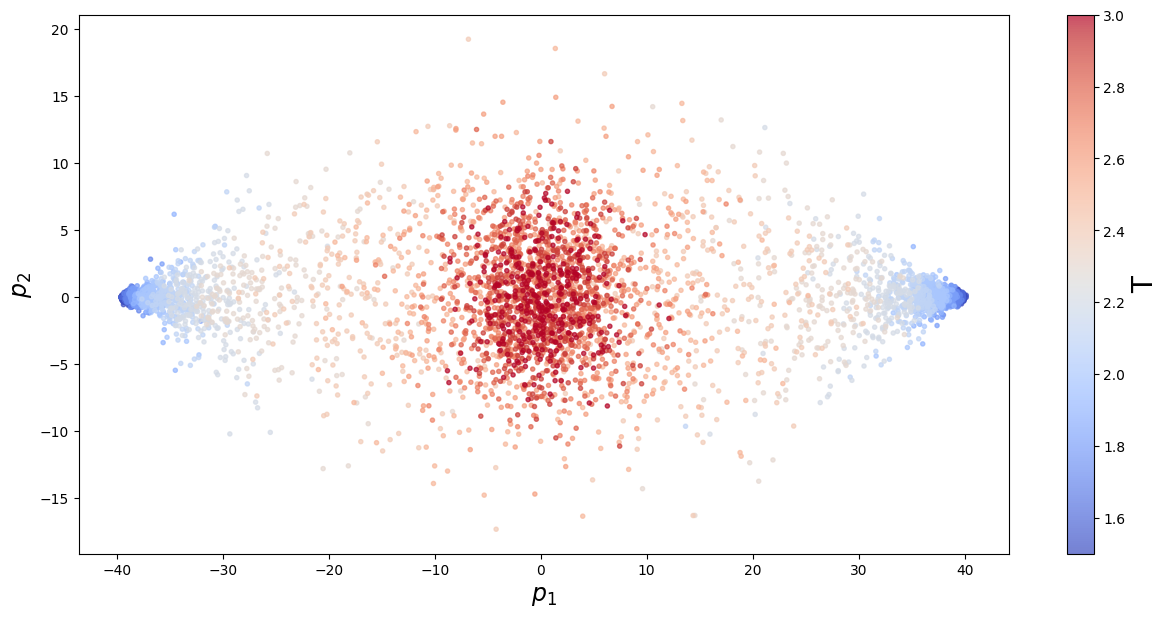

In [215]:
fig, ax = plt.subplots(figsize=(15, 7))

scatter = ax.scatter(p1, p2, c=y, cmap='coolwarm', alpha=0.7, marker='.')
ax.set_ylabel(r'$p_2$', fontsize=17)
ax.set_xlabel(r'$p_1$', fontsize=17)

cbar = fig.colorbar(scatter)
cbar.set_label('T', fontsize=20)


In [216]:
# fig.savefig('./results/dilute_ising/[1]/p2_v_p1.png')

### Clustering with KMeans

In [304]:
reduced_data = PCA(n_components=2).fit_transform(X30)
p1 = reduced_data[:, 0]
p2 = reduced_data[:, 1]
y = y30

kmeans = KMeans(init="k-means++", n_clusters=3, n_init=4)
kmeans.fit(reduced_data)

KMeans(n_clusters=3, n_init=4)

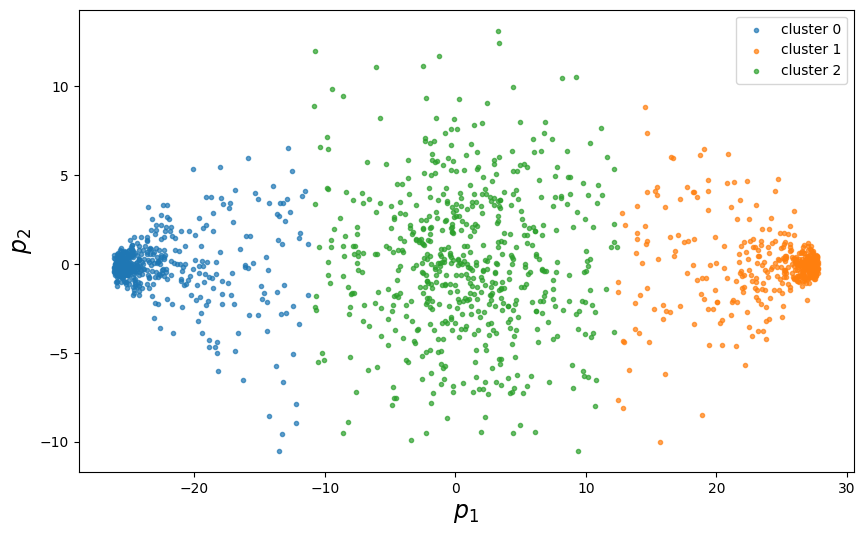

In [305]:
fig, ax = plt.subplots(figsize=(10, 6))

cluster0 = reduced_data[kmeans.labels_ == 0]
cluster1 = reduced_data[kmeans.labels_ == 1]
cluster2 = reduced_data[kmeans.labels_ == 2]

ax.scatter(cluster0[:, 0], cluster0[:, 1], alpha=0.7, marker='.', label='cluster 0')
ax.scatter(cluster1[:, 0], cluster1[:, 1], alpha=0.7, marker='.', label='cluster 1')
ax.scatter(cluster2[:, 0], cluster2[:, 1], alpha=0.7, marker='.', label='cluster 2')

ax.set_ylabel(r'$p_2$', fontsize=17)
ax.set_xlabel(r'$p_1$', fontsize=17)
ax.legend()

In [313]:
above_cluster = 2

In [306]:
# fig.savefig('./results/dilute_ising/[1]/kmeans.png')

### Tc from clustered temperatures 

### Alg 1: Tc to maximise number of ordered below and number of disordered above. Seems like a bad method actually

Tc is the expectation value of the temperature w.r.t the weight

The weight is the proportion of ordered states below + the proportion of disordered states above

weighted variance = [(w1*(x1 - weighted mean)^2 + w2*(x2 - weighted mean)^2 + ... + wn*(xn - weighted mean)^2)] / (w1 + w2 + ... + wn)

Take the square root of the weighted variance to get the weighted standard deviation.

In [307]:
def weight(labels, index): # preportion of ordered below + preportion of ordered above
    O_B = np.count_nonzero(labels[:index])
    O_A = np.count_nonzero(labels[index:])
    D_B = len(labels[:index]) - O_B
    D_A = len(labels[index:]) - O_A
    
    if O_B+O_A+D_B+D_A != len(labels):
        raise ValueError('somethings wrong brev')
    
    preportion_ordered_below = O_B/(O_A + O_B)
    preportion_disordered_above = D_A/(D_A + D_B)
    
    if (preportion_ordered_below==0) or (preportion_disordered_above==0): # ignore the non-overlap points
        return 0
    else:
        return preportion_ordered_below + preportion_disordered_above

def find_Tc(y, labels, central_limit=True):
    weights = np.array([weight(labels, i) for i in range(len(y))])
    data = y 
    
    # Calculate the weighted mean
    weighted_mean = np.average(data, weights=weights)

    # Calculate the standard error of the weighted mean
    weighted_variance = np.average((data - weighted_mean) ** 2, weights=weights)
    weighted_std_error = np.sqrt(weighted_variance / len(data))

    return weighted_mean, weighted_std_error

In [308]:
labels = kmeans.labels_
y = y # should already be in order ascending order

Tc, err = find_Tc(y, labels)

print(str(round(Tc, 4)) + ' +- '+ str(round(err, 5)))

1.6264 +- 0.01004


In [309]:
# Generate some random temperature data and binary labels
y = y
x = []
for e in kmeans.labels_:
    if e==0:
        x.append(1)
    else:
        x.append(0)
x = np.array(x)

### Kmeans

In this example, we first generate some random temperature data in the y array and binary labels in the x array. We then create a k-means clusterer using the KMeans class from the sklearn.cluster module with two clusters, corresponding to the two binary labels, and fit it to the temperature data and binary labels.

We then extract the cluster centroids from the k-means model using the cluster_centers_ attribute. The critical temperature is then calculated as the midpoint between the two cluster centroids.

Finally, we print out the critical temperature.

In [310]:
from sklearn.cluster import KMeans

# Create a k-means clusterer with two clusters and fit it to the data
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(y.reshape(-1, 1), x)

# Extract the critical temperature from the cluster centroids
centroids = kmeans.cluster_centers_
critical_temperature = (centroids[0] + centroids[1]) / 2

print("Critical temperature:", critical_temperature[0])


Critical temperature: 1.8660401721664286


/Users/willknott/Desktop/computingProjects/Potts/potts_venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


### Logistic regression

In this example, we first generate some random temperature data in the y array and binary labels in the x array. We then create a logistic regression model using the LogisticRegression class from the sklearn.linear_model module and fit it to the temperature data and binary labels.

We then use the logistic regression model to predict the binary labels for a range of temperatures using the predict method. We then find the index of the temperature at which the predicted labels change from 0 to 1 using the np.where function, and extract the corresponding temperature value from the temperatures array.

Logistic regression is a statistical model used to analyze the relationship between a dependent binary variable and one or more independent variables. It is a type of classification algorithm used to predict the probability of an event occurring.

In binary logistic regression, the dependent variable is binary, and the model uses a logistic function to model the probability of the dependent variable taking on the value 1. The logistic function is a sigmoidal curve that outputs a value between 0 and 1, representing the probability of the event occurring.

The logistic regression algorithm learns the relationship between the independent variables and the dependent variable by minimizing a cost function using a training set of data. The cost function measures the difference between the predicted probability of the model and the actual label of the training data.

In the provided code, logistic regression is used to find the critical temperature. The temperature is the independent variable, and the binary labels indicating whether the temperature is above or below the critical temperature are the dependent variable. The logistic regression algorithm learns the relationship between the temperature and the binary labels by minimizing the cost function.

Once the logistic regression model is trained on the data, the critical temperature can be calculated by finding the temperature where the predicted probability of being above the critical temperature is 0.5. This is the decision boundary between the two classes, and it represents the critical temperature.

In [311]:
from sklearn.linear_model import LogisticRegression

# Convert y to a numpy array
y = np.array(y).reshape(-1, 1)

# Create a logistic regression model
model = LogisticRegression()

# Fit the model using the data
model.fit(y, x)

# Predict the critical temperature
critical_temp = -model.intercept_[0] / model.coef_[0][0]

print("The critical temperature is:", critical_temp)

The critical temperature is: 1.4687167500899203


### Alg 2: Using the overlap 

1. Find the highest Tbelow and lowest Tabove. 
2. If Tbelow >= Tabove then calculate the midpoint and record as an estimate of Tc.
3. Throw these readings away and the next highest Tbelow and next lowest Tabove.
4. Repeat until the highest Tbelow < highest Tabove

In [312]:
filt0 = labels==0 # below Tc
filt1 = labels==1 # above
filt2 = labels==2 # above

Tabove = y[filt0]
Tbelow = np.concatenate((y[filt1], y[filt2]))

Tabove = np.sort(Tabove)
Tbelow = np.sort(Tbelow)

# overlap_T = set(Tabove).intersection(set(Tbelow))

criticals = []
highest_below = 9999
lowest_above = -9999
i = 0
while highest_below >= lowest_above:
    lowest_above = Tabove[i]  
    highest_below = Tbelow[-(i+1)]
    if highest_below >= lowest_above:
        criticals.append((highest_below+lowest_above)/2)
    i += 1

criticals = np.array(criticals)
Tc = np.mean(criticals)
err = np.std(criticals)

Tc

2.0299573560767588

In [87]:
Tabove[-1]

2.7

### DBSCAN for bad data (method_2 data)